# Big Data y Machine Learning (UBA) 

## Trabajo Práctico 1: Jugando con APIs y WebScraping 

### Reglas de formato y presentación
- El trabajo debe estar debidamente documentado comentado (utilizando #) para que tanto los docentes como sus compañeros puedan comprender el código fácilmente.

- El mismo debe ser completado en este Jupyter Notebook y entregado como tal, es decir en un archivo .ipynb


### Fecha de entrega:
<font color=red>Martes 31 de Marzo a las 13:00 hs</font> 

### Modalidad de entrega
- Al finalizar el trabajo práctico deben hacer un último <i>commit</i> en su repositorio de GitHub llamado “Entrega final del tp”. 
- Asegurense de haber creado una carpeta llamada TP1. Este Jupyter Notebook y el correspondiente al TP1 deben estar dentro de esa carpeta.
- También deben incorporar el link de su repositorio -para que pueda ser clonado y corregido- en su informe final. Nombrar los archivos <i>"UBA_TP1_Grupo_#"</i> donde # es el número de grupo que le fue asignado.
- La última versión en el repositorio es la que será evaluada. Por lo que es importante que: 
    - No envien el correo hasta no haber terminado y estar seguros de que han hecho el <i>commit y push</i> a la versión final que quieren entregar. 
    - No hagan nuevos <i>push</i> despues de haber entregado su versión final. Esto generaría confusión acerca de que versión es la que quieren que se les corrija.
- En resumen, la carpeta del repositorio debe incluir:
    - El codigo
    - Un documento Word (Parte A) donde esten las figuras y una breve descripción de las mismas.
    - El excel con los links webscrappeados (Parte B)
    - Slides para presentar en el sorteo de exposición grupal

### Parte A

#### Ejercicio 1 - Jugando con APIs
Usando la API del Series de Tiempo de la Republica Argentina [link](https://datosgobar.github.io/series-tiempo-ar-api/applications/) , obtener 2 (dos) series de indicadores del **Ministerio de Justicia y Derechos Humanos de la Nación**. En total, dicho Ministerio tiene **575** series anuales y pueden buscar dos series de indicadores de su interés.

In [1]:
# Resolver acá
import requests
import pandas as pd
import matplotlib.pyplot as plt   # Cada uno de estos submodulos importados me di cuenta que los utilizaba claude en el gráfico posterior y entonces, para escribir menos, decidí importarlos directamente acá
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

## APIs work | Sneep id - Ministerio de Justicia de la Nación

La idea detrás de estas dos series de tiempo que tomamos -Población Carcelaria Total y Personas **Procesadas** Privadas de Libertad- es mostrar el hacinamiento debido a personas que aún no han sido sentenciadas pero que ocupan recursos y lugares del sistema de justicia. 

In [ ]:
BASE_URL = "https://apis.datos.gob.ar/series/api/series/"
 
params = {                                      # El url preciso que mostró NR no lo encontré pero supuse que sale de "https://datosgobar.github.io/series-tiempo-ar-call-generator/" y, por esa razón, mejor utilicé los parámetros para hacer gets que ya definió el gobierno
    "ids": "sneep_pto_arg,sneep_p_arg",         # pto_arg es la población total y pto_arg es la cantidad de procesados
    "format": "json",
    "limit": 100,                               # El límite de 100 lo puse porque por ahí la API te trae mucho menos automáticamente. Se puede ver más abajo que hay solo 18 y 23 filas de procesados y problación total respectivamente
}
 
response = requests.get(BASE_URL, params=params)
data = response.json()
 
data



{'data': [['2002-01-01', 44969.0, 26477.0],
  ['2003-01-01', 42687.0, 25117.0],
  ['2004-01-01', 53029.0, 31043.0],
  ['2005-01-01', 43689.0, 24232.0],
  ['2006-01-01', 50428.0, 29052.0],
  ['2007-01-01', 50980.0, 29972.0],
  ['2008-01-01', 53448.0, 31389.0],
  ['2009-01-01', 54758.0, 30409.0],
  ['2010-01-01', 58917.0, 30832.0],
  ['2011-01-01', 60106.0, 30305.0],
  ['2012-01-01', 61192.0, 30643.0],
  ['2013-01-01', 64109.0, 31785.0],
  ['2014-01-01', 68407.0, 34613.0],
  ['2015-01-01', 71464.0, 35779.0],
  ['2016-01-01', 76261.0, 36374.0],
  ['2017-01-01', 85283.0, 38315.0],
  ['2018-01-01', 94883.0, 43597.0],
  ['2019-01-01', 100634.0, 43752.0],
  ['2020-01-01', 94944.0, None],
  ['2021-01-01', 101267.0, None],
  ['2022-01-01', 105053.0, None],
  ['2023-01-01', 111967.0, None],
  ['2024-01-01', 120700.0, None]],
 'count': 23,
 'meta': [{'frequency': 'year',
   'start_date': '2002-01-01',
   'end_date': '2024-01-01'},
  {'catalog': {'title': 'Datos Justicia Argentina'},
   'dataset':

In [5]:
# Construcción dataframe

registros = data["data"]
df = pd.DataFrame(registros, columns=["fecha", "poblacion_total", "procesados"])
df["fecha"] = pd.to_datetime(df["fecha"])     # Las fechas en el df bajado de seguro no las lee pandas como fechas (sino como string) y con esta línea las convierto a formato fecha para después poder trabajar con ellas
df = df.sort_values("fecha").reset_index(drop=True) # Me aseguro de ordenar el df por fecha y el reset_index(drop=True) es para tirar el índice viejo que se guarda automáticamente en el df
 
print("Vista previa de los datos:")
print(df.head())

Vista previa de los datos:
       fecha  poblacion_total  procesados
0 2002-01-01          44969.0     26477.0
1 2003-01-01          42687.0     25117.0
2 2004-01-01          53029.0     31043.0
3 2005-01-01          43689.0     24232.0
4 2006-01-01          50428.0     29052.0


#### Ejercicio 2 - Repaso de Pandas
Realicen una estadistica descriptiva ambas series de indicadores del Ministerio y  presente en una tabla en su reporte. Dicha tabla debe mostrar: numero de observaciones, media, desvío standard, min, p25, mediana, p75 y max. Comente la tabla en **el reporte**.

In [ ]:
# Resolver acá

df[["procesados", "poblacion_total"]].describe().round(0) #redondeamos cero décimas... son personas

,procesados,poblacion_total
count,18.0,23.0
mean,32427.0,72573.0
std,5479.0,24102.0
min,24232.0,42687.0
25%,30055.0,53238.0
50%,30938.0,64109.0
75%,35488.0,94914.0
max,43752.0,120700.0


#### Ejercicio 3 - Practicando con Matplotlib
Armen dos gráficos de tendencia distintos usando la librería Matplotlib (repasen Clase 2). Uno programándolo con el estilo `pyplot` y otro gráfico de estilo `orientada a objetos`.
Recuerde los principios de visualización de datos y comente dichas figuras en su reporte.

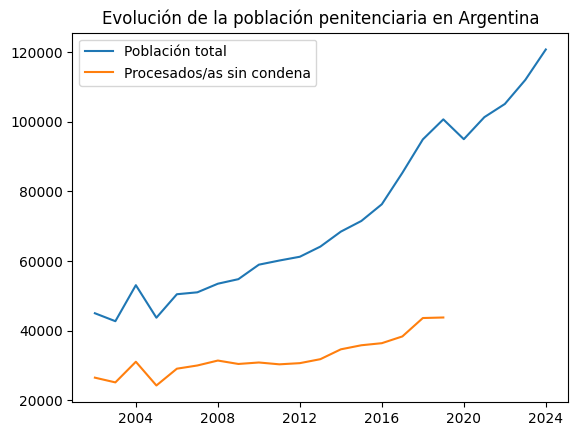

In [19]:
# Resolver acá estilo pyplot
 
plt.plot(df["fecha"], df["poblacion_total"], label="Población total")
plt.plot(df["fecha"], df["procesados"], label="Procesados/as sin condena")

plt.title("Evolución de la población penitenciaria en Argentina")
plt.legend()
plt.savefig("graf_sneep_pyplot.pdf", bbox_inches="tight")
plt.show()     # Busqué y encontré que esta función es para mostrar el gráfico sin que te salga un output raro con él

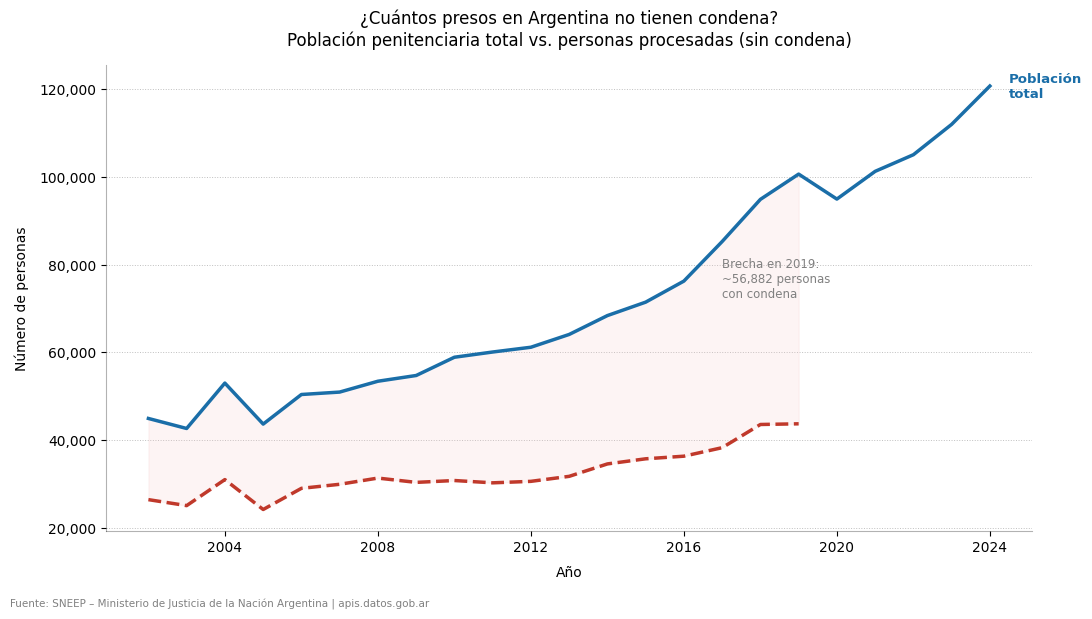

In [18]:
# Resolver acá estilo orientado-objetos 
# Tip: aprovechar este estilo de programar una figura para hacerlo más lindo 

fig, ax = plt.subplots(figsize=(11, 6))
 
COLOR_TOTAL      = "#1a6ea8"
COLOR_PROCESADOS = "#c0392b"
COLOR_BRECHA     = "#f5c6c6"
 
# Área sombreada = brecha entre total y procesados
ax.fill_between(df["fecha"], df["procesados"], df["poblacion_total"],
                alpha=0.18, color=COLOR_BRECHA, label="_nolegend_")
 
# Líneas principales
ax.plot(df["fecha"], df["poblacion_total"], color=COLOR_TOTAL,
        linewidth=2.5, zorder=3)
ax.plot(df["fecha"], df["procesados"], color=COLOR_PROCESADOS,
        linewidth=2.5, linestyle="--", zorder=3)
 
# --- Etiquetas directas al final de cada línea ---
ultimo = df.iloc[-1]
ax.text(ultimo["fecha"] + pd.DateOffset(months=6),
        ultimo["poblacion_total"],
        "Población\ntotal", color=COLOR_TOTAL,
        fontsize=9.5, va="center", fontweight="bold")
ax.text(ultimo["fecha"] + pd.DateOffset(months=6),
        ultimo["procesados"],
        "Procesados/as\nsin condena", color=COLOR_PROCESADOS,
        fontsize=9.5, va="center", fontweight="bold")
 
# --- Eliminar bordes (Schwabish: reducir chartjunk) ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)
 
# --- Grilla sutil solo horizontal ---
ax.yaxis.grid(True, linestyle=":", linewidth=0.7, color="grey", alpha=0.5)
ax.set_axisbelow(True)
 
# --- Formato eje Y con separador de miles ---
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
 
# --- Títulos y etiquetas ---
ax.set_title(
    "¿Cuántos presos en Argentina no tienen condena?\n"
    "Población penitenciaria total vs. personas procesadas (sin condena)",
    fontsize=12, loc="center", pad=14
)
ax.set_xlabel("Año", fontsize=10, labelpad=8)
ax.set_ylabel("Número de personas", fontsize=10, labelpad=8)

ultimo_proc = df["procesados"].last_valid_index()

val_proc  = df.loc[ultimo_proc, "procesados"]
val_total = df.loc[ultimo_proc, "poblacion_total"]
fecha_proc = df.loc[ultimo_proc, "fecha"]   # <-- la fecha de ese índice
anio      = fecha_proc.year

brecha = int(val_total - val_proc)

ax.annotate(
    f"Brecha en {anio}:\n~{brecha:,} personas\ncon condena",
    xy=(fecha_proc, (val_total + val_proc) / 2),
    xytext=(fecha_proc - pd.DateOffset(years=2), val_total * 0.72),
    fontsize=8.5, color="grey",
)
 
# --- Fuente ---
fig.text(0.01, -0.02,
         "Fuente: SNEEP – Ministerio de Justicia de la Nación Argentina | apis.datos.gob.ar",
         fontsize=7.5, color="grey")
 
plt.tight_layout()
plt.savefig("graf_sneep_comparison.pdf", bbox_inches="tight")
plt.show()

### Parte B

#### Ejercicio 4 - Documentando noticias locales y en el extranjero
Eligan dos sitios web de noticias: uno de Argentina y uno del extranjero (puede ser en castellano o en inglés como el *New York Times*).

Utilicen herramientas de webscraping para obtener los **links** de las noticias de la portada en ambos diarios. Guarden cada titular con los links obtenidos en un dataframe. Por lo tanto, debe quedarles un dataframe de 4 columnas: una columna para noticias locales, otra para su link, otra columna de noticias extranjeras y una ultima columna de sus links. Luego, expórtenlo a un archivo de excel.

En el reporte este esta parte B:
1) Inserten una captura de pantalla de la pagina del diario extranjero y en Argentina de las cuales hacen el ejercicio de extraer titulares y sus links correspondientes. Esto servirá al momento de la corrección para verificar que los links obtenidos hacen referencia a las noticias de ese día y hora.
2) Comenten brevemente (1 párrafo) las diferencias/similitudes al extraer titulares en diarios de Argentina versus diario extranjero
3) Comenten brevemente (1 párrafo) las dificultades y cómo resolvieron dichas dificultades.

*Nota*: es posible que logren obtener los links a las noticias sin el dominio: por ejemplo "https://www.lanacion.com.ar/". De ser así, concatenen el dominio a la ruta del link obtenido, tal que se obtenga un link al que se pueda acceder. Es decir, que las cadenas de caracteres finales tendrán la forma: https://www.lanacion.com.ar/*texto_obtenido*)

In [ ]:
# Resolver acá
